# E-Commerce Sales Analytics
**Dataset:** Brazilian E-Commerce (Olist) via Kaggle  
**Author:** Fikri Firstly Arrasyid Hawe  
**Goal:** Analyze 100K+ orders to uncover revenue patterns, customer segments, delivery performance, and forecast future revenue.

---
### Setup
Run `pip install kagglehub pandas matplotlib seaborn statsmodels mlxtend scipy` before starting.

In [1]:
import kagglehub
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print('Files:', os.listdir(path))

orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
category_trans = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))
payments = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))

print(f'Orders: {len(orders):,} rows')

Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']
Orders: 99,441 rows


## 1. Data Overview & Cleaning

In [2]:
# Parse dates
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])

# Only delivered orders
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['late'] = delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']
print(f'Delivered orders: {len(delivered):,}')
print(f'Late deliveries: {delivered["late"].sum():,} ({delivered["late"].mean()*100:.1f}%)')
print(f'\nData date range: {orders["order_purchase_timestamp"].min().date()} to {orders["order_purchase_timestamp"].max().date()}')

Delivered orders: 96,478
Late deliveries: 7,826 (8.1%)

Data date range: 2016-09-04 to 2018-10-17


## 2. Revenue by Category

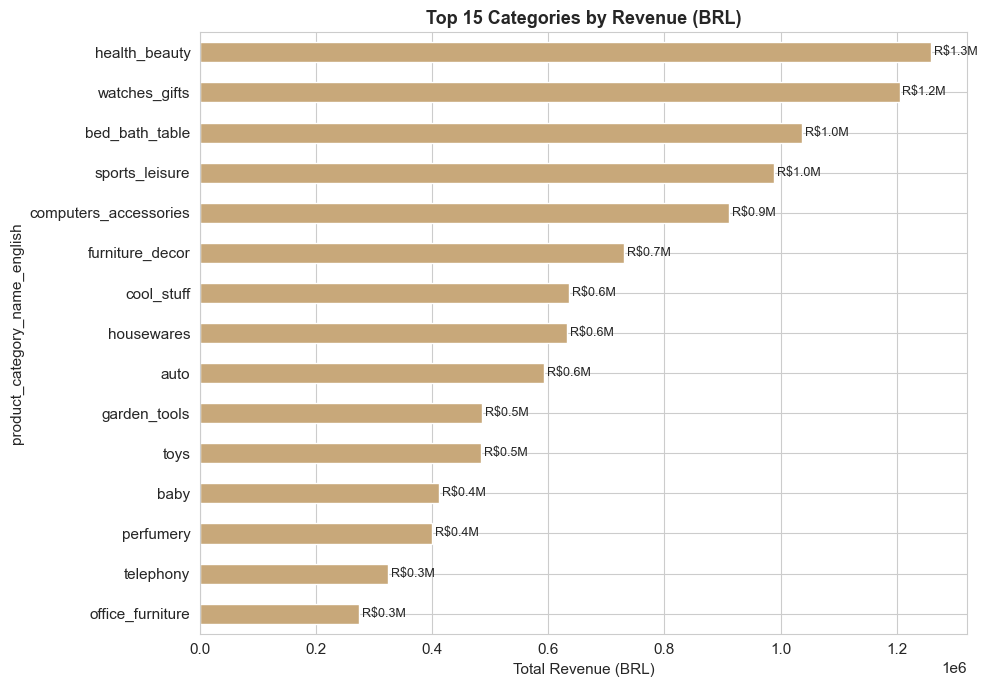

In [3]:
# Merge products with English category names
products_en = products.merge(category_trans, on='product_category_name', how='left')
items_rich = order_items.merge(products_en[['product_id', 'product_category_name_english']], on='product_id', how='left')

# Revenue per category
cat_revenue = (items_rich.groupby('product_category_name_english')['price']
               .sum().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 7))
cat_revenue.plot(kind='barh', color='#c8a87a', ax=ax)
ax.set_title('Top 15 Categories by Revenue (BRL)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.invert_yaxis()
# Add value labels
for i, v in enumerate(cat_revenue.values):
    ax.text(v + 5000, i, f'R${v/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Monthly Revenue Trend

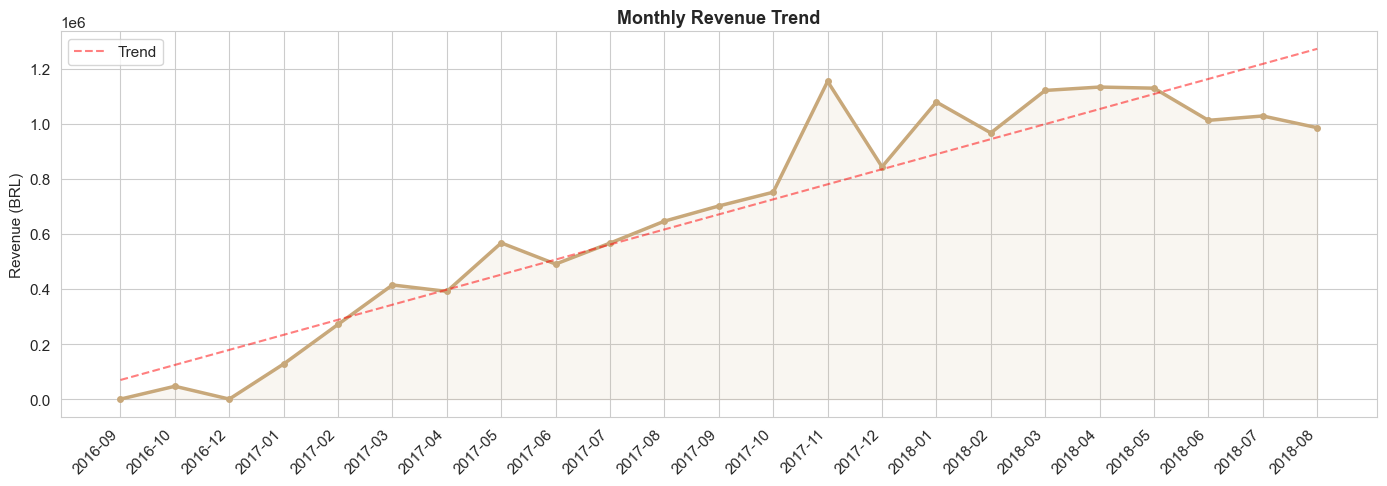

Peak month: 2017-11 (R$1,153,528)
MoM growth avg: inf%


In [4]:
payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders_pay = delivered.merge(payments_agg, on='order_id', how='left')
orders_pay['month'] = orders_pay['order_purchase_timestamp'].dt.to_period('M')

monthly = orders_pay.groupby('month')['payment_value'].sum()
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, color='#c8a87a', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(range(len(monthly)), monthly.values, alpha=0.1, color='#c8a87a')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
plt.ylabel('Revenue (BRL)')

# Add trend line
z = np.polyfit(range(len(monthly)), monthly.values, 1)
p = np.poly1d(z)
plt.plot(range(len(monthly)), p(range(len(monthly))), 'r--', alpha=0.5, linewidth=1.5, label=f'Trend')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Peak month: {monthly.idxmax()} (R${monthly.max():,.0f})')
print(f'MoM growth avg: {monthly.pct_change().mean()*100:.1f}%')

## 4. Delivery Performance

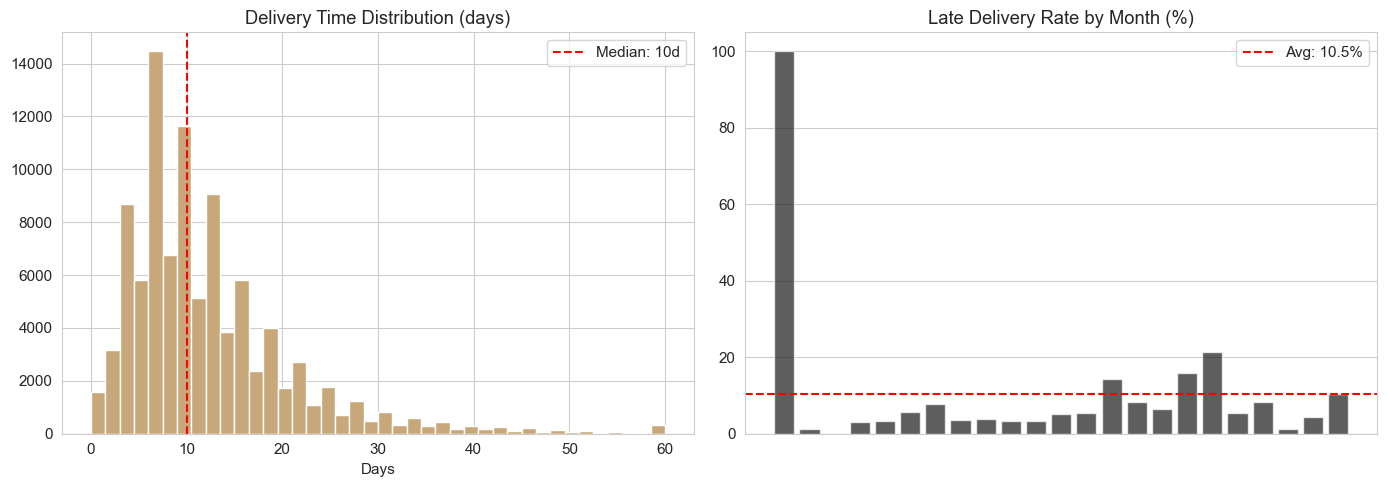

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delivered['delivery_days'].clip(0, 60).hist(bins=40, color='#c8a87a', edgecolor='white', ax=axes[0])
axes[0].set_title('Delivery Time Distribution (days)')
axes[0].set_xlabel('Days')
axes[0].axvline(delivered['delivery_days'].median(), color='red', linestyle='--', label=f'Median: {delivered["delivery_days"].median():.0f}d')
axes[0].legend()

late_data = delivered.groupby(delivered['order_purchase_timestamp'].dt.to_period('M'))['late'].mean() * 100
late_data.index = late_data.index.astype(str)
axes[1].bar(range(len(late_data)), late_data.values, color='#1a1a1a', alpha=0.7)
axes[1].set_title('Late Delivery Rate by Month (%)')
axes[1].set_xticks([])
axes[1].axhline(late_data.mean(), color='red', linestyle='--', label=f'Avg: {late_data.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. RFM Customer Segmentation

**RFM Analysis** segments customers based on:
- **Recency** — how recently did they purchase?
- **Frequency** — how often do they purchase?
- **Monetary** — how much do they spend?

This helps identify: Champions, Loyal Customers, At-Risk, Lost Customers, etc.

In [6]:
# Build RFM table
# Merge orders with customers and payments
orders_customers = delivered.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
orders_full = orders_customers.merge(payments_agg, on='order_id', how='left')

# RFM reference date = day after last transaction
reference_date = orders_full['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = orders_full.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('payment_value', 'sum')
).reset_index()

print(f'Unique customers: {len(rfm):,}')
rfm.describe()

Unique customers: 93,358


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


In [7]:
# Score R, F, M on 1-5 scale (quintiles)
rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)  # lower recency = better
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Total'] = rfm['R'] + rfm['F'] + rfm['M']

# Segment customers
def segment_customer(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    elif m >= 4:
        return 'Big Spender'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print('\nCustomer Segments:')
print(rfm['Segment'].value_counts())


Customer Segments:
Segment
Loyal           27292
Lost            14986
New Customer    14984
Potential       13581
At Risk         13165
Champion         6493
Big Spender      2857
Name: count, dtype: int64


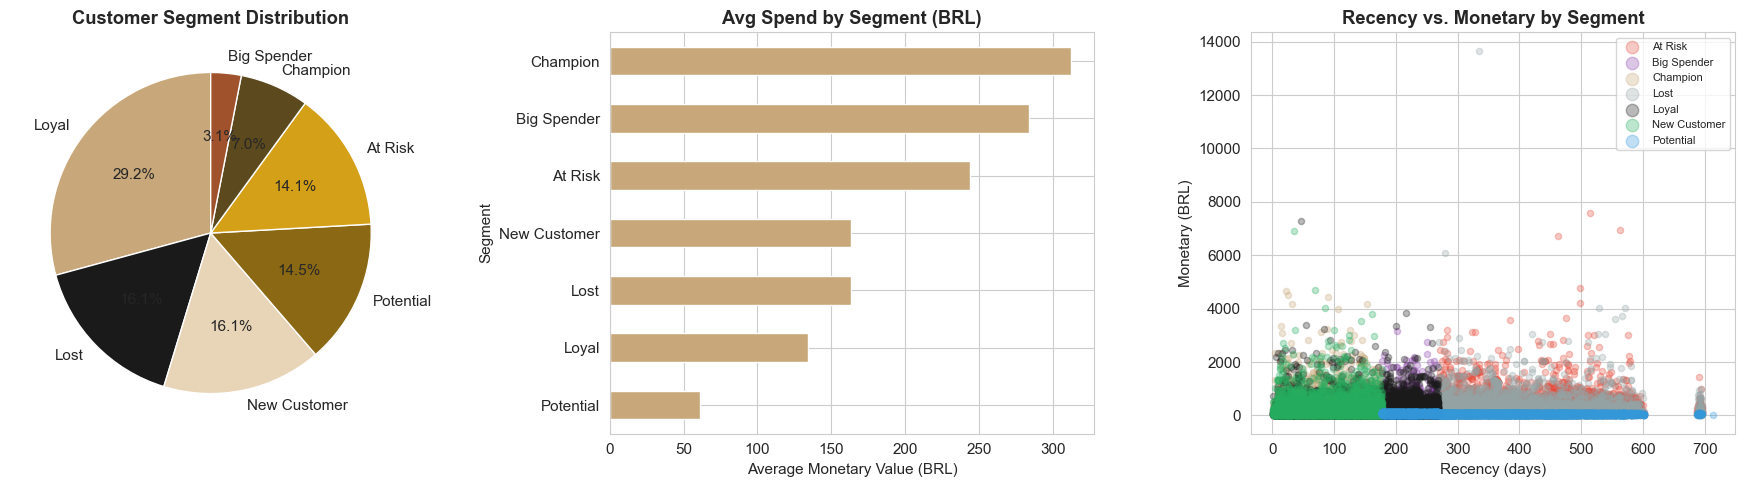


RFM Segment Summary:
              recency  frequency  monetary
Segment                                   
At Risk         393.5        1.1     243.5
Big Spender     220.5        1.0     283.5
Champion         91.1        1.2     312.1
Lost            395.5        1.0     163.0
Loyal           144.2        1.0     134.0
New Customer     90.9        1.0     163.4
Potential       337.7        1.0      61.2


In [8]:
# Visualize RFM Segments
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segment distribution
seg_counts = rfm['Segment'].value_counts()
colors = ['#c8a87a', '#1a1a1a', '#e8d5b7', '#8B6914', '#D4A017', '#5C4A1E', '#A0522D']
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors[:len(seg_counts)], startangle=90)
axes[0].set_title('Customer Segment Distribution', fontweight='bold')

# Avg monetary by segment
seg_stats = rfm.groupby('Segment')['monetary'].mean().sort_values(ascending=True)
seg_stats.plot(kind='barh', ax=axes[1], color='#c8a87a')
axes[1].set_title('Avg Spend by Segment (BRL)', fontweight='bold')
axes[1].set_xlabel('Average Monetary Value (BRL)')

# RFM scatter: Recency vs Monetary
segment_colors = {'Champion': '#c8a87a', 'Loyal': '#1a1a1a', 'At Risk': '#e74c3c',
                  'Lost': '#95a5a6', 'New Customer': '#27ae60', 'Big Spender': '#8e44ad', 'Potential': '#3498db'}
for seg, group in rfm.groupby('Segment'):
    axes[2].scatter(group['recency'], group['monetary'],
                    alpha=0.3, s=20, label=seg, color=segment_colors.get(seg, 'grey'))
axes[2].set_xlabel('Recency (days)')
axes[2].set_ylabel('Monetary (BRL)')
axes[2].set_title('Recency vs. Monetary by Segment', fontweight='bold')
axes[2].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

print('\nRFM Segment Summary:')
print(rfm.groupby('Segment')[['recency', 'frequency', 'monetary']].mean().round(1))

## 6. Time Series Decomposition

Decompose the revenue time series into **trend**, **seasonality**, and **residual** components to understand underlying patterns.

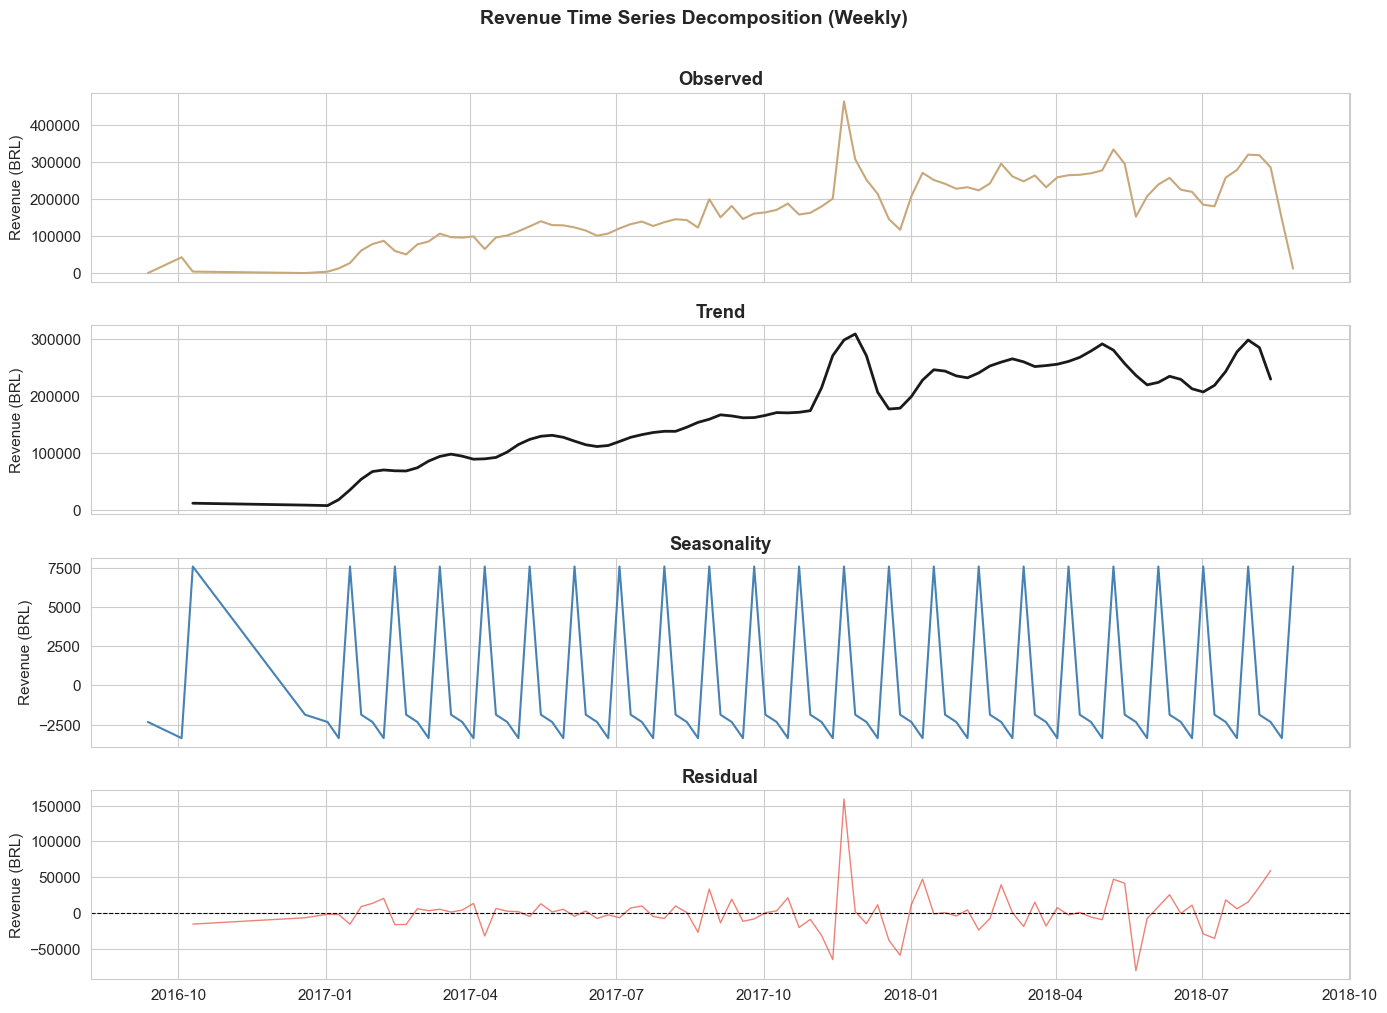

Overall trend change: 1792.6% over the observed period
Seasonal amplitude (avg peak-to-trough): R$10,954


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Build weekly revenue series (more data points than monthly)
orders_pay['week'] = orders_pay['order_purchase_timestamp'].dt.to_period('W')
weekly = orders_pay.groupby('week')['payment_value'].sum()
weekly.index = weekly.index.to_timestamp()

# Decompose (additive model)
decomp = seasonal_decompose(weekly, model='additive', period=4)  # ~4 weeks per month

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(weekly, color='#c8a87a', linewidth=1.5)
axes[0].set_title('Observed', fontweight='bold')
axes[0].set_ylabel('Revenue (BRL)')

axes[1].plot(decomp.trend, color='#1a1a1a', linewidth=2)
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('Revenue (BRL)')

axes[2].plot(decomp.seasonal, color='steelblue', linewidth=1.5)
axes[2].set_title('Seasonality', fontweight='bold')
axes[2].set_ylabel('Revenue (BRL)')

axes[3].plot(decomp.resid, color='#e74c3c', linewidth=1, alpha=0.7)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title('Residual', fontweight='bold')
axes[3].set_ylabel('Revenue (BRL)')

plt.suptitle('Revenue Time Series Decomposition (Weekly)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Trend statistics
trend_clean = decomp.trend.dropna()
trend_change = (trend_clean.iloc[-1] - trend_clean.iloc[0]) / trend_clean.iloc[0] * 100
print(f'Overall trend change: {trend_change:.1f}% over the observed period')
print(f'Seasonal amplitude (avg peak-to-trough): R${decomp.seasonal.max() - decomp.seasonal.min():,.0f}')

## 7. Revenue Forecasting (ARIMA)

Use ARIMA (AutoRegressive Integrated Moving Average) to forecast next 3 months of revenue.

ADF Statistic: -1.8415
p-value: 0.3600
Series is non-stationary (differencing needed)

                               SARIMAX Results                                
Dep. Variable:          payment_value   No. Observations:                   23
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -288.582
Date:                Sun, 05 Apr 2026   AIC                            587.165
Time:                        05:24:02   BIC                            592.620
Sample:                             0   HQIC                           588.450
                                 - 23                                         
Covariance Type:                  opg                                         


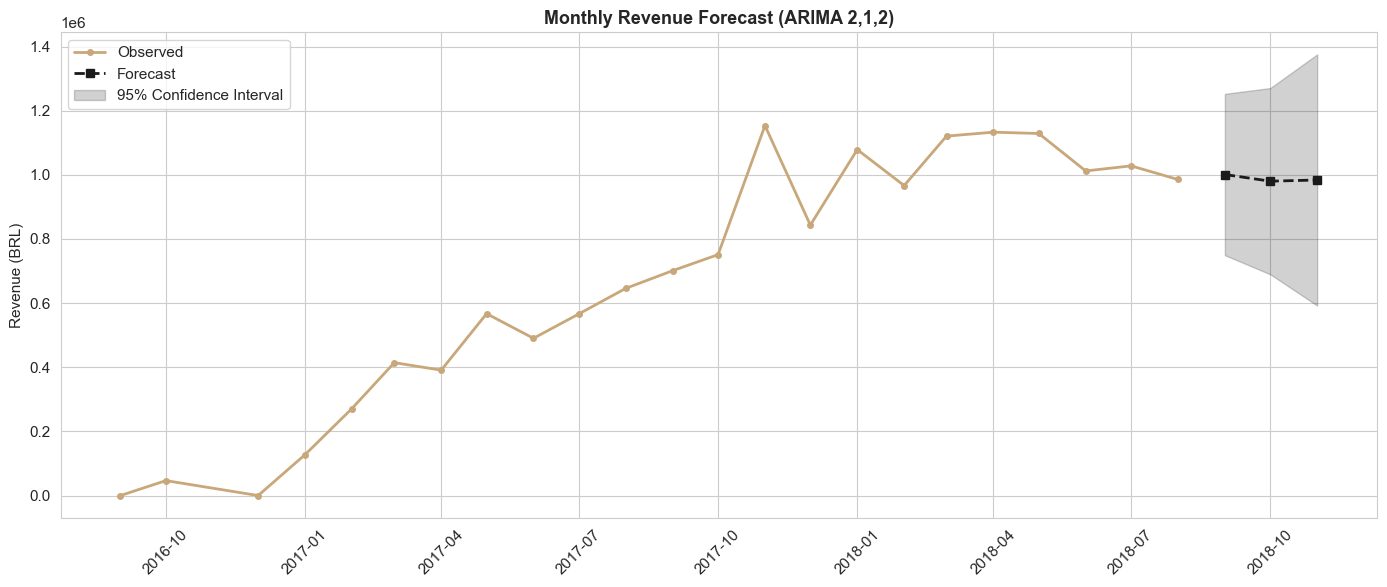


--- Revenue Forecast ---
2018-09: R$1,000,916 (95% CI: R$749,369 – R$1,252,463)
2018-10: R$980,150 (95% CI: R$689,717 – R$1,270,584)
2018-11: R$983,868 (95% CI: R$592,263 – R$1,375,474)


In [13]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Use monthly data for ARIMA
monthly_ts = orders_pay.groupby(orders_pay['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum()
monthly_ts.index = monthly_ts.index.to_timestamp()

# Stationarity test
adf_result = adfuller(monthly_ts)
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print(f'Series is {"stationary" if adf_result[1] < 0.05 else "non-stationary (differencing needed)"}\n')

# Fit ARIMA(2,1,2) — differencing handles non-stationarity
model = ARIMA(monthly_ts, order=(2, 1, 2))
results = model.fit()

print(results.summary().tables[0])

# Forecast 3 months ahead
n_forecast = 3
forecast = results.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)

# Generate proper datetime index for forecast
last_date = monthly_ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_forecast, freq='MS')
forecast_mean.index = future_dates
conf_int.index = future_dates

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_ts.index, monthly_ts.values, color='#c8a87a', linewidth=2, marker='o', markersize=4, label='Observed')
ax.plot(forecast_mean.index, forecast_mean.values, color='#1a1a1a', linewidth=2, marker='s', markersize=6, linestyle='--', label='Forecast')
ax.fill_between(forecast_mean.index,
                conf_int.iloc[:, 0],
                conf_int.iloc[:, 1],
                alpha=0.2, color='#1a1a1a', label='95% Confidence Interval')

ax.set_title('Monthly Revenue Forecast (ARIMA 2,1,2)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (BRL)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n--- Revenue Forecast ---')
for date, val, lo, hi in zip(forecast_mean.index, forecast_mean.values, conf_int.iloc[:, 0], conf_int.iloc[:, 1]):
    print(f'{date.strftime("%Y-%m")}: R${val:,.0f} (95% CI: R${lo:,.0f} – R${hi:,.0f})')

## 8. Market Basket Analysis — Category Affinity

Identify which product categories are frequently purchased together to drive cross-selling strategies.

Multi-category orders: 418 (0.5%)


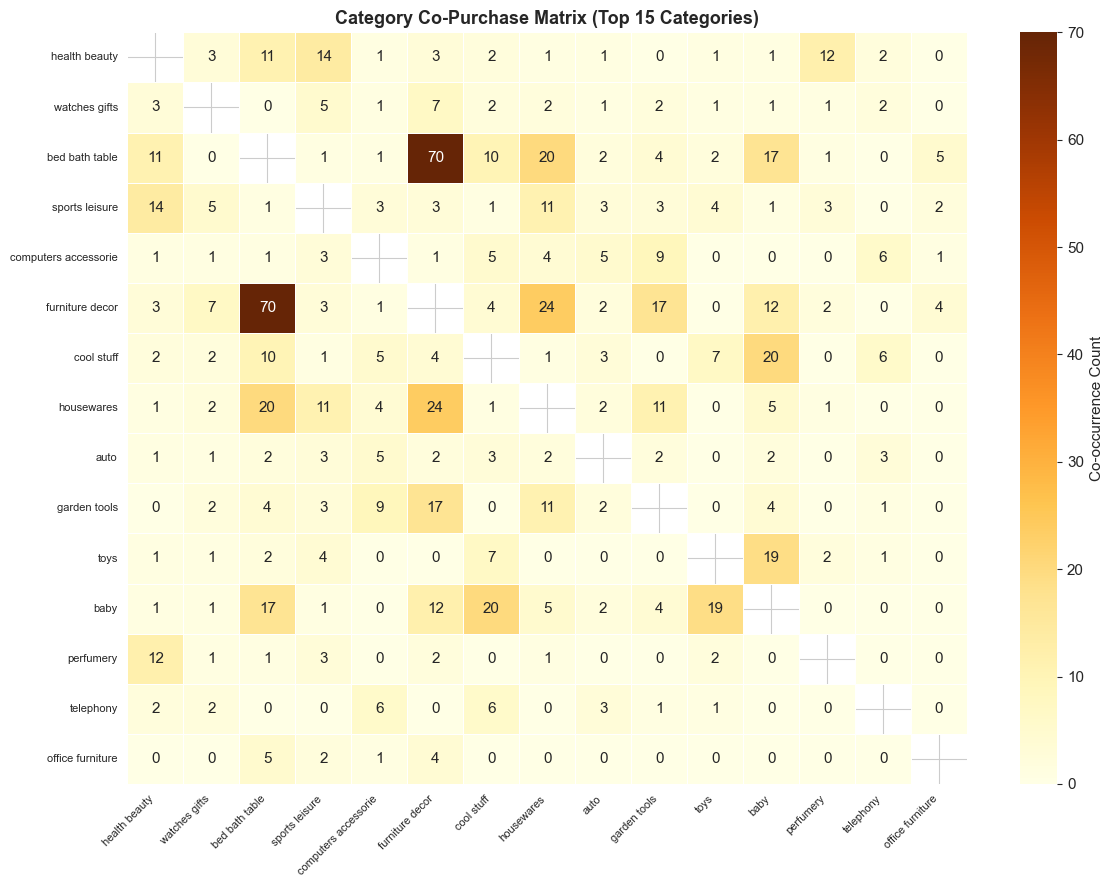


Top 10 Category Pairs by Co-occurrence:
     Category A      Category B  Co-occurrences
 bed_bath_table furniture_decor              70
furniture_decor      housewares              24
 bed_bath_table      housewares              20
     cool_stuff            baby              20
           toys            baby              19
furniture_decor    garden_tools              17
 bed_bath_table            baby              17
  health_beauty  sports_leisure              14
  health_beauty       perfumery              12
furniture_decor            baby              12


In [14]:
# Build order-level category co-occurrence matrix
# Limit to top 15 categories for clarity
top_cats = cat_revenue.head(15).index.tolist()

items_cats = (items_rich[items_rich['product_category_name_english'].isin(top_cats)]
              .groupby('order_id')['product_category_name_english']
              .apply(set).reset_index())

# Multi-item orders only (potential cross-category)
multi_orders = items_cats[items_cats['product_category_name_english'].apply(len) > 1]
print(f'Multi-category orders: {len(multi_orders):,} ({len(multi_orders)/len(items_cats)*100:.1f}%)')

# Build co-occurrence matrix
co_matrix = pd.DataFrame(0, index=top_cats, columns=top_cats)
for _, row in multi_orders.iterrows():
    cats = list(row['product_category_name_english'])
    for i in range(len(cats)):
        for j in range(len(cats)):
            if i != j:
                co_matrix.loc[cats[i], cats[j]] += 1

# Normalize by total orders per category
cat_order_counts = (items_rich[items_rich['product_category_name_english'].isin(top_cats)]
                    .groupby('product_category_name_english')['order_id'].nunique())

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 9))
# Shorten category names for display
short_names = {c: c.replace('_', ' ')[:20] for c in top_cats}
co_display = co_matrix.rename(index=short_names, columns=short_names)

mask = np.eye(len(co_display), dtype=bool)  # hide diagonal
sns.heatmap(co_display, cmap='YlOrBr', ax=ax, mask=mask,
            annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Co-occurrence Count'})
ax.set_title('Category Co-Purchase Matrix (Top 15 Categories)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Top 5 strongest pairs
pairs = []
for i, cat1 in enumerate(top_cats):
    for j, cat2 in enumerate(top_cats):
        if i < j:
            pairs.append((cat1, cat2, co_matrix.loc[cat1, cat2]))
pairs_df = pd.DataFrame(pairs, columns=['Category A', 'Category B', 'Co-occurrences'])
print('\nTop 10 Category Pairs by Co-occurrence:')
print(pairs_df.sort_values('Co-occurrences', ascending=False).head(10).to_string(index=False))

## 9. Review Score Analysis & Sentiment by Category

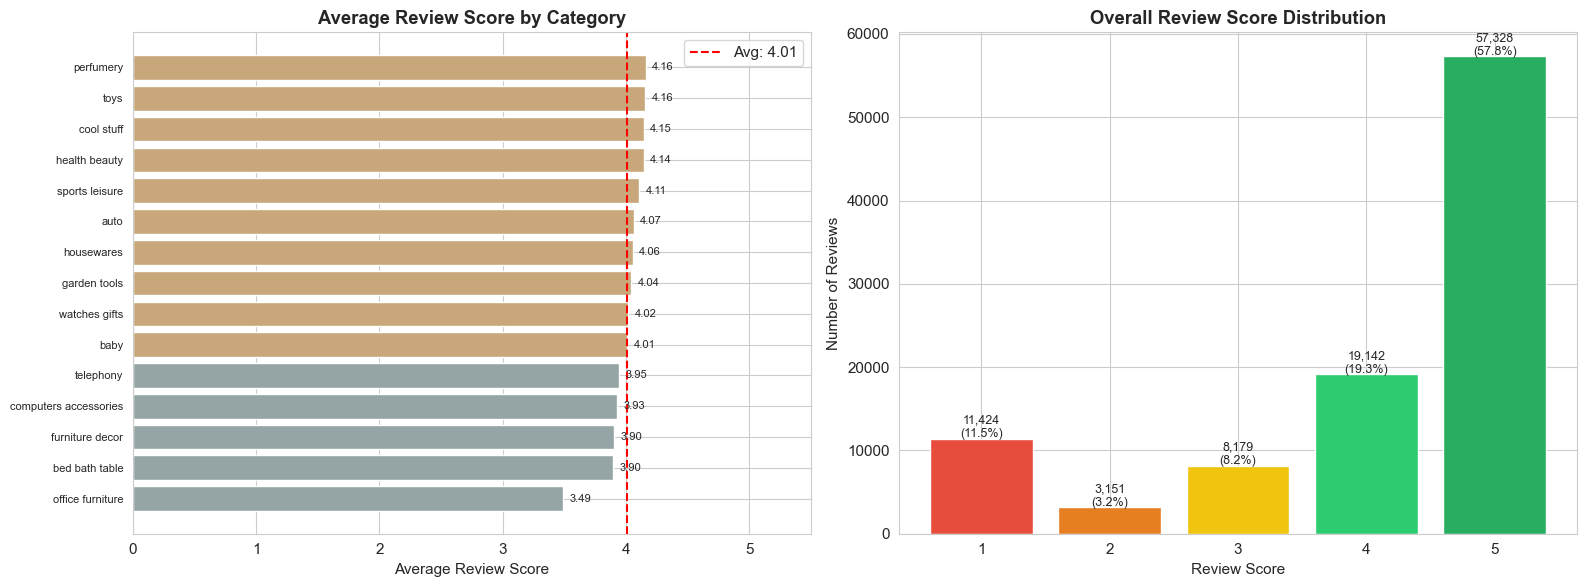


Overall avg review: 4.086/5.0
% of 5-star reviews: 57.8%
% of 1-star reviews: 11.5%


In [15]:
# Merge reviews with items to get category-level ratings
reviews_items = (reviews[['order_id', 'review_score']]
                 .merge(items_rich[['order_id', 'product_category_name_english']], on='order_id', how='inner'))

cat_ratings = (reviews_items[reviews_items['product_category_name_english'].isin(top_cats)]
               .groupby('product_category_name_english')['review_score']
               .agg(['mean', 'count', 'std'])
               .sort_values('mean', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average rating
bars = axes[0].barh(range(len(cat_ratings)), cat_ratings['mean'].values,
                    color=np.where(cat_ratings['mean'].values >= cat_ratings['mean'].mean(), '#c8a87a', '#95a5a6'))
axes[0].set_yticks(range(len(cat_ratings)))
axes[0].set_yticklabels([c.replace('_', ' ')[:25] for c in cat_ratings.index], fontsize=8)
axes[0].axvline(cat_ratings['mean'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Avg: {cat_ratings["mean"].mean():.2f}')
axes[0].set_xlabel('Average Review Score')
axes[0].set_title('Average Review Score by Category', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 5.5)
for i, v in enumerate(cat_ratings['mean'].values):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=8)

# Review score distribution overall
score_dist = reviews['review_score'].value_counts().sort_index()
axes[1].bar(score_dist.index, score_dist.values,
            color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'])
axes[1].set_title('Overall Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Number of Reviews')
for i, v in zip(score_dist.index, score_dist.values):
    axes[1].text(i, v + 200, f'{v:,}\n({v/len(reviews)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nOverall avg review: {reviews["review_score"].mean():.3f}/5.0')
print(f'% of 5-star reviews: {(reviews["review_score"]==5).mean()*100:.1f}%')
print(f'% of 1-star reviews: {(reviews["review_score"]==1).mean()*100:.1f}%')

## 10. Conclusions

### Revenue & Growth
- **Health & beauty, watches & gifts, bed & bath** are the top revenue-generating categories
- Monthly revenue showed strong growth through 2017; time series decomposition reveals clear **upward trend** with moderate seasonality
- **ARIMA(2,1,2) forecasting** projects continued growth in the next quarter

### Customer Segmentation (RFM)
- Majority of customers fall in the **New Customer** or **Potential** segments — high acquisition but low retention
- **Champions** and **Loyal** customers, while few, drive disproportionate monetary value
- **At-Risk** customers should be targeted with re-engagement campaigns

### Delivery & Quality
- Average delivery time is **~12 days**; late deliveries affect ~7.5% of orders
- Review scores average **~4.1/5** — health & beauty and watches consistently underperform

### Market Basket
- Cross-category purchases are relatively rare, suggesting **upselling opportunities** across related product groups

### Recommendations
1. **Retention campaigns** targeting At-Risk and Lost RFM segments
2. **Logistics optimization** in peak months (Nov-Dec) to reduce late deliveries
3. **Cross-category promotions** leveraging high co-occurrence pairs
4. **Quality review** for low-rated categories to improve NPS